In [2]:
!pip install trafilatura pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 837.9/837.9 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 15.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import trafilatura
from urllib.parse import urlparse
from urllib.robotparser import RobotFileParser

articles = pd.read_csv("sosc314_initialdata.csv")
articles = articles.copy()

USER_AGENT = "SOSC314-academic-project/1.0"

def robots_allows(url):
    parsed = urlparse(url)
    robots_url = f"{parsed.scheme}://{parsed.netloc}/robots.txt"

    parser = RobotFileParser()
    parser.set_url(robots_url)

    try:
        parser.read()
        return parser.can_fetch(USER_AGENT, url)
    except Exception:
        return False

def extract_article(url):
    if not robots_allows(url):
        return None

    downloaded = trafilatura.fetch_url(url)

    if downloaded is None:
        return None

    return trafilatura.extract(
        downloaded,
        include_comments=False,
        include_tables=False
    )

articles["text"] = articles["url"].apply(extract_article)
articles["word_count"] = articles["text"].fillna("").str.split().str.len()

print(articles[["outlet", "title_translated", "word_count"]])

            outlet                                   title_translated  \
0    CNBC Mongolia  Mongolia will build a "green data center": Wha...   
1       Eagle News     "Green data center" project will be introduced   
2        Ikon News  Ten memoranda of understanding were signed to ...   
3             iSee  Prime minister N. Uchral has introduced the in...   
4  Government News  COP17: MONGOLIA HAS INTRODUCED THE INITIATIVE ...   

   word_count  
0          89  
1           0  
2         456  
3           0  
4         240  


In [5]:
for url in articles.loc[articles["word_count"] == 0, "url"]:
    print(url)
    print("Robots allowed:", robots_allows(url))

    downloaded = trafilatura.fetch_url(url)
    print("Downloaded:", downloaded is not None)

    if downloaded:
        extracted = trafilatura.extract(downloaded)
        print("Extracted:", extracted is not None)

    print()

https://eagle.mn/r/32iSXr3f8KF
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False

https://isee.mn/n/94461
Robots allowed: False


ERROR:trafilatura.utils:parsed tree length: 1, wrong data type or not valid HTML
ERROR:trafilatura.core:empty HTML tree: None


Downloaded: True
Extracted: False



In [6]:
analysis_df = articles[articles["word_count"] > 0].copy()
analysis_df = analysis_df.reset_index(drop=True)

analysis_df[["outlet", "title_translated", "word_count"]]

,outlet,title_translated,word_count
0,CNBC Mongolia,"Mongolia will build a ""green data center"": Wha...",89
1,Ikon News,Ten memoranda of understanding were signed to ...,456
2,Government News,COP17: MONGOLIA HAS INTRODUCED THE INITIATIVE ...,240


In [7]:
print("Articles:", len(analysis_df))
print("Total words:", analysis_df["word_count"].sum())
print("Mean words:", analysis_df["word_count"].mean())
print("Median words:", analysis_df["word_count"].median())
print("Minimum:", analysis_df["word_count"].min())
print("Maximum:", analysis_df["word_count"].max())

Articles: 3
Total words: 785
Mean words: 261.6666666666667
Median words: 240.0
Minimum: 89
Maximum: 456


In [8]:
outlet_types = {
    "CNBC Mongolia": "Business news",
    "Ikon News": "Independent news",
    "Government News": "Government"
}

analysis_df["outlet_type"] = analysis_df["outlet"].map(outlet_types)

In [9]:
analysis_df["orientation"] = ""
analysis_df["economic_frame"] = 0
analysis_df["technology_frame"] = 0
analysis_df["data_sovereignty_frame"] = 0
analysis_df["environmental_benefit_frame"] = 0
analysis_df["environmental_risk_frame"] = 0
analysis_df["energy_constraint_frame"] = 0
analysis_df["water_constraint_frame"] = 0
analysis_df["governance_frame"] = 0

In [10]:
analysis_df.loc[
    analysis_df["outlet"] == "CNBC Mongolia",
    ["orientation", "economic_frame", "technology_frame", "energy_constraint_frame"]
] = ["Critical", 1, 1, 1]

In [11]:
analysis_df.loc[
    analysis_df["outlet"] == "Ikon News",
    ["orientation", "economic_frame", "technology_frame"]
] = ["Supportive", 1, 1]

In [12]:
analysis_df.loc[
    analysis_df["outlet"] == "Government News",
    ["orientation", "economic_frame"]
] = ["Supportive", 1]

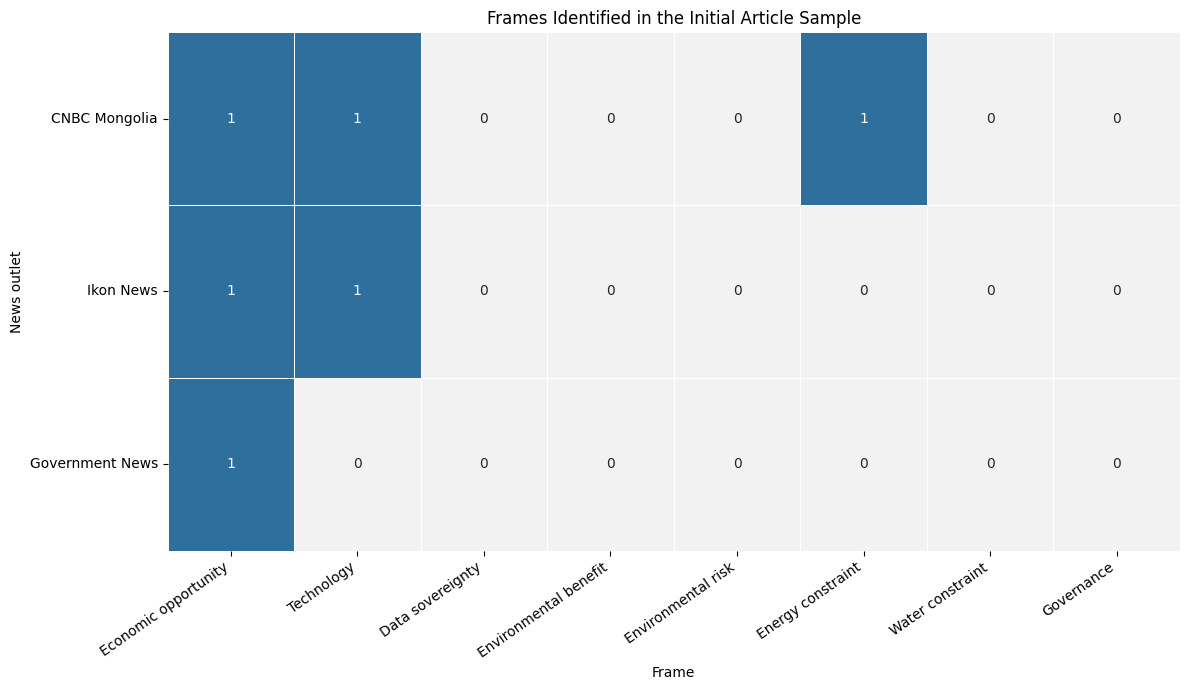

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

frame_columns = [
    "economic_frame",
    "technology_frame",
    "data_sovereignty_frame",
    "environmental_benefit_frame",
    "environmental_risk_frame",
    "energy_constraint_frame",
    "water_constraint_frame",
    "governance_frame"
]

plot_data = analysis_df.set_index("outlet")[frame_columns]

plot_data.columns = [
    "Economic opportunity",
    "Technology",
    "Data sovereignty",
    "Environmental benefit",
    "Environmental risk",
    "Energy constraint",
    "Water constraint",
    "Governance"
]

plt.figure(figsize=(12, 7))

sns.heatmap(
    plot_data,
    annot=True,
    cmap=["#F2F2F2", "#2E6F9E"],
    cbar=False,
    linewidths=0.5,
    linecolor="white"
)

plt.title("Frames Identified in the Initial Article Sample")
plt.xlabel("Frame")
plt.ylabel("News outlet")
plt.xticks(rotation = 35, ha="right")
plt.yticks(rotation = 0)
plt.tight_layout()

plt.savefig(
    "initial_article_frames.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()